# Panel 4 and 5

This notebook contains the majority of the images for the fourth and fifth panels of the paper, including the likelihood scans, and GP parameter fits. Data is imported from the fitted GPs, and from the saved likelihood scans.

In [52]:
# Autoreloading of modules and files without restarting notebook.
%reload_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
from pathlib import Path
from copy import deepcopy
from math import log10, floor
import matplotlib.pyplot as plt

from rvm_analysis.colours import get_cell_colour, generate_color_spectrum
from rvm_analysis.save_tools import save_in_folder
from rvm_analysis.plotting import plot_rainclouds

#! Force the backend back to matplotlib inline (after importing viziphant).
%matplotlib inline
print(plt.get_backend())

module://matplotlib_inline.backend_inline


These paths are required to have the GP fit and likelihood scan output results in order to run.

In [53]:
likelihood_scan_path: Path = Path("../Gaussian_Processes/PERIOD_SCOPE_RESULTS_200.npz")
gaussian_process_param_save_directory = Path("../Gaussian_Processes/gpytorch_models/results/gen_pois_no_exp/")
image_save_path: Path = Path("./Images")
hyperparameter_dataframe_name = "combined_data.csv"

In [54]:
gp_likelihood_data = dict(np.load(likelihood_scan_path))
gp_likelihood_data

{'param_values': array([1.00000000e-01, 7.63718593e+00, 1.51743719e+01, 2.27115578e+01,
        3.02487437e+01, 3.77859296e+01, 4.53231156e+01, 5.28603015e+01,
        6.03974874e+01, 6.79346734e+01, 7.54718593e+01, 8.30090452e+01,
        9.05462312e+01, 9.80834171e+01, 1.05620603e+02, 1.13157789e+02,
        1.20694975e+02, 1.28232161e+02, 1.35769347e+02, 1.43306533e+02,
        1.50843719e+02, 1.58380905e+02, 1.65918090e+02, 1.73455276e+02,
        1.80992462e+02, 1.88529648e+02, 1.96066834e+02, 2.03604020e+02,
        2.11141206e+02, 2.18678392e+02, 2.26215578e+02, 2.33752764e+02,
        2.41289950e+02, 2.48827136e+02, 2.56364322e+02, 2.63901508e+02,
        2.71438693e+02, 2.78975879e+02, 2.86513065e+02, 2.94050251e+02,
        3.01587437e+02, 3.09124623e+02, 3.16661809e+02, 3.24198995e+02,
        3.31736181e+02, 3.39273367e+02, 3.46810553e+02, 3.54347739e+02,
        3.61884925e+02, 3.69422111e+02, 3.76959296e+02, 3.84496482e+02,
        3.92033668e+02, 3.99570854e+02, 4.071080

In [55]:
gp_likelihood_data_copy = deepcopy(gp_likelihood_data)

## Combine the two neutral datasets for plotting

In [56]:
gp_likelihood_data_copy['NEUTRAL_combined'] = np.hstack((gp_likelihood_data_copy['NEUTRAL'],gp_likelihood_data_copy['NEUTRAL_extra']))
print(gp_likelihood_data_copy['NEUTRAL_combined'].shape)

(200, 32)


In [57]:
fontsize = 7
plt.rcParams['savefig.pad_inches'] = 0
plt.rcParams["xtick.labelsize"] = fontsize
plt.rcParams["ytick.labelsize"] = fontsize

# Plot period scopes

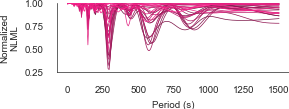

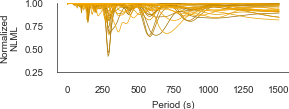

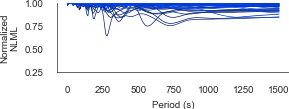

In [58]:
def plot_period_scopes(likelihood_data,save_path: Path):
    """
    Plots the period scopes obtained from the Periodic Gaussian process fit.
    """
    for key in ['ON','OFF','NEUTRAL_combined']:
    
        fig, ax = plt.subplots(figsize=(3, 0.9))
        plt.xlabel("Period (s)",fontsize=fontsize)
        plt.grid(False)
        plt.ylabel("Normalized\nNLML",fontsize=fontsize)
        ax.spines[['right', 'top']].set_visible(False)

        Y = likelihood_data[key]
        colors = generate_color_spectrum(get_cell_colour(names=key.split('_')[0]),Y.shape[1],var_size=0.4)

        for i, row in enumerate(Y.T):
            ax.plot(likelihood_data['param_values'],row/np.max(row),color=colors[i],linewidth=0.5)
        ax.set_yticks([0.25,0.5, 0.75, 1.0])
        ax.set_ylim(0.25,1.0)

        save_in_folder(f"period_scope_{key}",save_path,svg=True,save=True)

plot_period_scopes(gp_likelihood_data_copy,save_path=image_save_path)

## Plotting GP parameter fits

            model_id cell_name  id  lengthscale  period_length  outputscale  \
0               ON_0        ON   0     0.732044     290.712268     4.606016   
1               ON_1        ON   1     0.740650     289.767818     5.607834   
2               ON_2        ON   2     0.744271     290.009250     6.764927   
3               ON_3        ON   3     0.721765     298.802854     1.141226   
4               ON_4        ON   4     0.724499     293.381321     8.326621   
..               ...       ...  ..          ...            ...          ...   
77   NEUTRAL_EXTRA_7   NEUTRAL   7     0.744354     295.739407     0.000027   
78   NEUTRAL_EXTRA_8   NEUTRAL   8     0.747298     330.264028     0.050691   
79   NEUTRAL_EXTRA_9   NEUTRAL   9     0.744381     325.084969     0.000015   
80  NEUTRAL_EXTRA_10   NEUTRAL  10     0.738723     309.084340     0.101636   
81  NEUTRAL_EXTRA_11   NEUTRAL  11     0.736847     414.885138     0.028995   

           w  noise_prob  Train Model ELPD  Train M

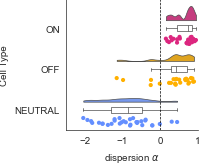

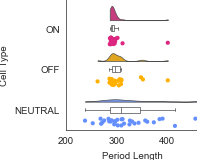

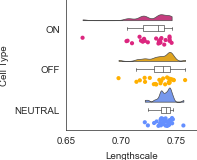

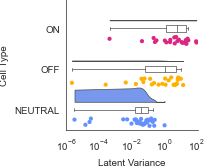

c:\Users\carla\Documents\Cambridge\PhD\Scripts\Spike2_Data_Analysis\env\lib\site-packages\seaborn\categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
c:\Users\carla\Documents\Cambridge\PhD\Scripts\Spike2_Data_Analysis\env\lib\site-packages\seaborn\categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
c:\Users\carla\Documents\Cambridge\PhD\Scripts\Spike2_Data_Analysis\env\lib\site-packages\seaborn\categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a futu

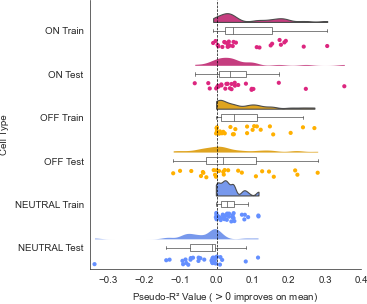

In [59]:
custom_palette={
    "ON Train": get_cell_colour(names="ON"),
    "ON Test": get_cell_colour(names="ON"),
    "OFF Train": get_cell_colour(names="OFF"),
    "OFF Test": get_cell_colour(names="OFF"),
    "NEUTRAL Train": get_cell_colour(names="NEUTRAL"),
    "NEUTRAL Test": get_cell_colour(names="NEUTRAL"),
}
custom_palette_w={
    "ON": get_cell_colour(names="ON"),
    "OFF": get_cell_colour(names="OFF"),
    "NEUTRAL": get_cell_colour(names="NEUTRAL"),
}

def plot_kernel_results_from_path(data_path: Path,kernel_name: str, dataframe_name: str, save_path: Path):
    """
    Plots the parameter fits of the Poisson GP kernel,
    taking a path to the directory where the saved parameters are located,
    and the name of the kernel (model shorthand) for saving only.
    """
    with open(os.path.join(data_path,dataframe_name)) as data_csv:
        df = pd.read_csv(data_csv)
        print(df)

        size = 1.7
        fig, ax = plt.subplots(figsize=(size,size))
        plot_rainclouds(data_csv,'w',df,xlim=[-2.5,1.0],move=0.3,
                        custom_palette=custom_palette_w, ax=ax, xlabel="dispersion $\\alpha$")
        save_in_folder(f"{kernel_name}_w",basePath="./Images",svg=True,save=True)


        fig, ax = plt.subplots(figsize=(size,size))
        plot_rainclouds(data_csv,'period_length',df,xlim=[200,460.0],move=0.3,
                        custom_palette=custom_palette_w, ax=ax, xlabel="Period Length")
        save_in_folder(f"{kernel_name}_period_length",basePath="./Images",svg=True,save=True)

        fig, ax = plt.subplots(figsize=(size,size))
        plot_rainclouds(data_csv,'lengthscale',df,xlim=[0.65,0.77],move=0.3,
                        custom_palette=custom_palette_w, ax=ax, xlabel="Lengthscale")
        save_in_folder(f"{kernel_name}_lengthscale",basePath="./Images",svg=True,save=True)

        fig, ax = plt.subplots(figsize=(size,size))
        plot_rainclouds(data_csv,'outputscale',df,xlim=[1e-6,120.0],move=0.3,
                        custom_palette=custom_palette_w, ax=ax, xlabel="Latent Variance")
        ax.set_xscale("log")
        save_in_folder(f"{kernel_name}_outputscale",basePath="./Images",svg=True,save=True)


    # Load the data
    df = pd.read_csv(os.path.join(data_path, "combined_data.csv"))

    train: pd.DataFrame = df[['cell_name', 'Train Pseudo-R2']].copy() #type: ignore
    train['cell_name'] = train['cell_name'] + ' Train'
    train = train.rename(columns={'Train Pseudo-R2': 'Pseudo-R2'}) #type: ignore

    test: pd.DataFrame = df[['cell_name', 'Test Pseudo-R2']].copy() #type: ignore
    test['cell_name'] = test['cell_name'] + ' Test'
    test = test.rename(columns={'Test Pseudo-R2': 'Pseudo-R2'})# type: ignore


    # Combine into one long-format DataFrame
    df_combined: pd.DataFrame = pd.concat([test, train], ignore_index=True)
    df_combined['cell_name'] = pd.Categorical(df_combined['cell_name'],categories=custom_palette.keys(),ordered=False)
    df_sorted=df_combined
    df_sorted = df_combined.sort_values('cell_name')
    # print(df_sorted)
    # Plot
    f, ax = plt.subplots(figsize=(3.5, 3.5))
    plot_rainclouds(None, 'Pseudo-R2', df_sorted, xlim=[-0.35, 0.4], ax=ax,
                    custom_palette=custom_palette,move=0.3,cloud_linewidths = [0.8,0.0,0.8,0.0,0.8,0.0]
    )

    # laeset_position((-0.2,0.5))
    # plt.tight_layout(h_pad=0.6)
    save_in_folder(f"{kernel_name}_r2_plot",save_path,svg=True,save=True)

plot_kernel_results_from_path(kernel_name="periodic",
                              data_path = gaussian_process_param_save_directory, dataframe_name=hyperparameter_dataframe_name,save_path=image_save_path)


## Printing GP hyperparameter value statistics

In [60]:
def get_param(param_name,data_path: Path,dataframe_name: str):
        """ Gets the mean, standard deviation, and count of a parameter. """
        with open(data_path / dataframe_name) as data_csv:
                df = pd.read_csv(data_csv)

                print(df.groupby('cell_name')[param_name].mean())
                print(df.groupby('cell_name')[param_name].std())
                print(df.groupby('cell_name')[param_name].count())

In [61]:
get_param("lengthscale",
        data_path= gaussian_process_param_save_directory, dataframe_name = hyperparameter_dataframe_name
        )

get_param("period_length",
        data_path= gaussian_process_param_save_directory, dataframe_name = hyperparameter_dataframe_name
        )

# This is alpha
get_param("w",
        data_path= gaussian_process_param_save_directory, dataframe_name = hyperparameter_dataframe_name
        )

get_param("outputscale",
        data_path= gaussian_process_param_save_directory, dataframe_name = hyperparameter_dataframe_name
        )

cell_name
NEUTRAL    0.739846
OFF        0.735455
ON         0.727108
Name: lengthscale, dtype: float64
cell_name
NEUTRAL    0.006811
OFF        0.013252
ON         0.017968
Name: lengthscale, dtype: float64
cell_name
NEUTRAL    32
OFF        25
ON         25
Name: lengthscale, dtype: int64
cell_name
NEUTRAL    322.272352
OFF        303.528035
ON         296.627912
Name: period_length, dtype: float64
cell_name
NEUTRAL    54.375143
OFF        27.177708
ON         22.386307
Name: period_length, dtype: float64
cell_name
NEUTRAL    32
OFF        25
ON         25
Name: period_length, dtype: int64
cell_name
NEUTRAL   -0.901351
OFF        0.361914
ON         0.626146
Name: w, dtype: float64
cell_name
NEUTRAL    0.628561
OFF        0.533125
ON         0.254833
Name: w, dtype: float64
cell_name
NEUTRAL    32
OFF        25
ON         25
Name: w, dtype: int64
cell_name
NEUTRAL     0.102625
OFF         3.114473
ON         17.172766
Name: outputscale, dtype: float64
cell_name
NEUTRAL     0.197648
O

In [62]:
params = ["period_length", "w", "outputscale","lengthscale", ]

def format_sigfig_no_sci(x, sig=2):
    """
    Formats a number to `sig` significant figures without scientific notation.
    """
    if pd.isna(x):
        return ""

    if x == 0:
        return "0"

    # number of digits before decimal
    power = floor(log10(abs(x)))

    # digits after decimal
    decimals = sig - power - 1
    decimals = max(decimals, 0)
    fmt = "{:." + str(decimals) + "f}"
    out = fmt.format(x)

    out = out.rstrip("0").rstrip(".")
    return out

def make_latex_table(base_save_dir: Path, dataframe_name: str, output_tex_path="param_table.tex"):
    """
    Makes a latex table with the output parameter values in it.
    """
    df = pd.read_csv(os.path.join(base_save_dir, dataframe_name))

    rows = []
    cell_names = df['cell_name'].unique()

    for cell in cell_names:
        row = [cell]
        cell_df = df[df['cell_name'] == cell]

        for p in params:
            mean_val = cell_df[p].mean()
            std_val  = cell_df[p].std()

            mean_f = format_sigfig_no_sci(mean_val, 2)
            std_f  = format_sigfig_no_sci(std_val, 2)

            row.append(f"{mean_f} \\pm {std_f}")

        rows.append(row)

    # Build the table
    header = "Cell & " + " & ".join(params) + " \\\\"
    latex = [
        "\\begin{table}[h!]",
        "\\centering",
        "\\begin{tabular}{l" + "c" * len(params) + "}",
        "\\hline",
        header,
        "\\hline"
    ]

    for r in rows:
        latex.append(" & ".join(r) + " \\\\")

    latex += [
        "\\hline",
        "\\end{tabular}",
        "\\caption{Parameter means $\\pm$ std (2 significant figures, no scientific notation).}",
        "\\end{table}"
    ]

    latex_text = "\n".join(latex)

    with open(output_tex_path, "w") as f:
        f.write(latex_text)

    print(f"LaTeX table written to {output_tex_path}")


make_latex_table(base_save_dir= gaussian_process_param_save_directory, dataframe_name = hyperparameter_dataframe_name
)


LaTeX table written to param_table.tex
